# Notebook 2: Relationships Between Type, Task, and Goal

This notebook examines how the three final labels relate to each other:

- `final_type`
- `final_task`
- `final_goal`

We are doing this because, in HCI and human-AI interaction research, a query is usually not just a question. It reflects a **behavioral structure**:

- the **kind of information** the user wants,
- the **task** they are trying to do with that information,
- and the **goal** they ultimately care about.

This notebook helps answer questions such as:

1. Do certain information types consistently support certain tasks?
2. Do certain tasks tend to serve certain goals?
3. Are there common behavioral pipelines, such as `recommendation → decision-making → purchase`?

This matters because it moves the analysis from simple counts to a more meaningful view of **how users operationalize AI in context**.

## 1. Import packages

We import the packages needed for data loading, tables, and visualizations.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)

## 2. Load the cleaned dataset

This notebook uses the cleaned file containing the final labels.

These columns are the focus here:

- `final_type`
- `final_task`
- `final_goal`

In [22]:
file_path = '../Reconciled_Final.csv'
df = pd.read_csv(file_path)

print('Shape:', df.shape)
df.head()

Shape: (2115, 6)


,participant_no,week_no,query,final_type,final_task,final_goal
0,102,Week 1,foods to avoid while losing body fat,ideas/options,option seeking,plan
1,102,Week 1,foods to avoid while losing body fat,ideas/options,option seeking,plan
2,102,Week 1,foods to eat that help lose weight,ideas/options,option seeking,plan
3,102,Week 1,foods to eat that help lose weight,ideas/options,option seeking,plan
4,102,Week 1,vegan foods to eat that help lose weight,ideas/options,option seeking,plan


## 3. Quick cleaning and structure check

Before measuring relationships, we make sure the key columns exist and remove rows where one of the final labels is missing.

Why this matters:
- Relationship tables become misleading if blank labels are mixed in.
- We want the cross-tabulations to reflect meaningful behavioral combinations.

In [23]:
required_cols = ['final_type', 'final_task', 'final_goal']
missing_required = [c for c in required_cols if c not in df.columns]
print('Missing required columns:', missing_required)

df[required_cols].isna().sum()

Missing required columns: []


final_type    0
final_task    0
final_goal    0
dtype: int64

In [24]:
rel_df = df.dropna(subset=required_cols).copy()
print('Rows kept for relationship analysis:', len(rel_df))
print('Rows removed due to missing labels:', len(df) - len(rel_df))

Rows kept for relationship analysis: 2115
Rows removed due to missing labels: 0


## 4. Type × Task relationship

This section examines whether certain kinds of information are associated with certain tasks.

Why this matters:
- It helps show whether users treat AI differently depending on the information form they request.
- For example, factual queries may cluster with learning, while recommendations may cluster with decision-making.
- In HCI terms, this shows how **information form maps onto user activity**.

In [25]:
type_task_counts = pd.crosstab(rel_df['final_type'], rel_df['final_task'])
type_task_counts

final_task,barrier,barrier,barrier management,evaluate,evalute,learn,logistics,na,option seeking,perform
final_type,,,,,,,,,,
comparative,0,0,0,26,0,0,0,0,0,0
experiential,0,4,0,26,0,43,0,0,1,2
factual,0,0,0,3,0,223,27,12,8,0
how-to,0,0,0,0,0,2,0,0,0,0
how-to (procedural),2,0,30,0,0,61,0,0,23,2
how-to (psyc),0,0,1,0,0,0,0,0,0,0
how-to (psychological),7,0,34,0,0,2,0,0,2,0
ideas,0,0,0,0,0,0,0,0,5,0
ideas/options,6,0,5,4,0,63,12,0,793,6


In [26]:
type_task_rowpct = pd.crosstab(rel_df['final_type'], rel_df['final_task'], normalize='index')
type_task_rowpct.round(3)

final_task,barrier,barrier,barrier management,evaluate,evalute,learn,logistics,na,option seeking,perform
final_type,,,,,,,,,,
comparative,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000
experiential,0.000,0.053,0.000,0.342,0.000,0.566,0.000,0.000,0.013,0.026
factual,0.000,0.000,0.000,0.011,0.000,0.817,0.099,0.044,0.029,0.000
how-to,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000
how-to (procedural),0.017,0.000,0.254,0.000,0.000,0.517,0.000,0.000,0.195,0.017
how-to (psyc),0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
how-to (psychological),0.156,0.000,0.756,0.000,0.000,0.044,0.000,0.000,0.044,0.000
ideas,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000
ideas/options,0.007,0.000,0.006,0.004,0.000,0.071,0.013,0.000,0.892,0.007


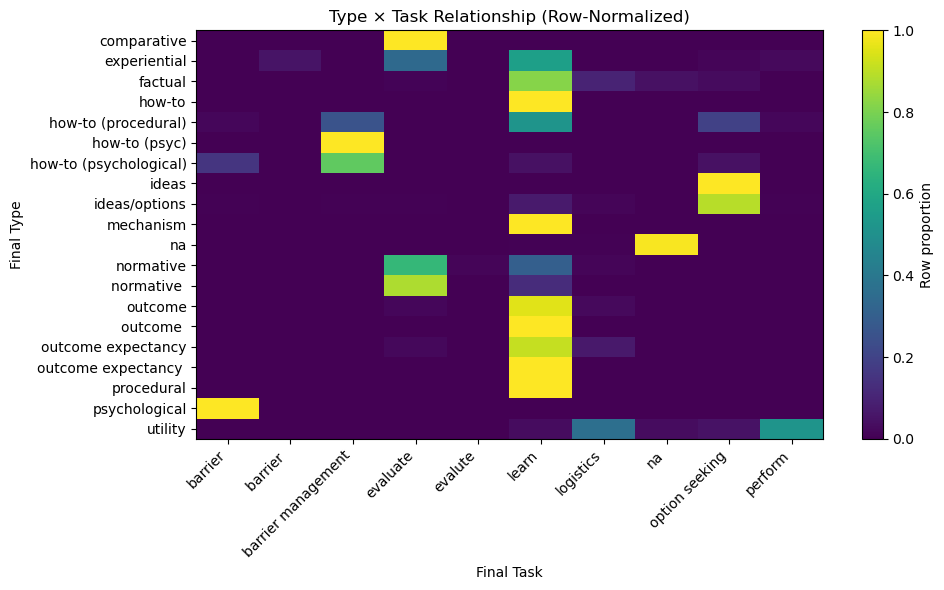

In [27]:
plt.figure(figsize=(10, 6))
plt.imshow(type_task_rowpct, aspect='auto')
plt.xticks(range(len(type_task_rowpct.columns)), type_task_rowpct.columns, rotation=45, ha='right')
plt.yticks(range(len(type_task_rowpct.index)), type_task_rowpct.index)
plt.colorbar(label='Row proportion')
plt.title('Type × Task Relationship (Row-Normalized)')
plt.xlabel('Final Task')
plt.ylabel('Final Type')
plt.tight_layout()
plt.show()

## 5. Task × Goal relationship

This section looks at whether specific tasks tend to serve specific goals.

Why this matters:
- Tasks represent **what the user is doing** with AI.
- Goals represent **why they are doing it**.
- This relationship helps us understand whether some tasks are strongly tied to practical outcomes, learning outcomes, or broader decision support.

In [28]:
task_goal_counts = pd.crosstab(rel_df['final_task'], rel_df['final_goal'])
task_goal_counts

final_goal,action,decision,decision making,motivational,motivational,motivational reasoning,na,plan
final_task,,,,,,,,
barrier,0,0,0,1,0,1,0,14
barrier,0,0,0,0,0,3,0,1
barrier management,3,0,0,25,0,15,0,27
evaluate,0,4,88,3,0,30,0,13
evalute,0,0,0,0,0,0,0,1
learn,20,3,72,33,7,117,0,457
logistics,33,0,9,0,0,1,1,32
na,10,0,2,0,0,0,203,10
option seeking,15,1,91,0,0,7,0,721


In [29]:
task_goal_rowpct = pd.crosstab(rel_df['final_task'], rel_df['final_goal'], normalize='index')
task_goal_rowpct.round(3)

final_goal,action,decision,decision making,motivational,motivational,motivational reasoning,na,plan
final_task,,,,,,,,
barrier,0.000,0.000,0.000,0.062,0.00,0.062,0.000,0.875
barrier,0.000,0.000,0.000,0.000,0.00,0.750,0.000,0.250
barrier management,0.043,0.000,0.000,0.357,0.00,0.214,0.000,0.386
evaluate,0.000,0.029,0.638,0.022,0.00,0.217,0.000,0.094
evalute,0.000,0.000,0.000,0.000,0.00,0.000,0.000,1.000
learn,0.028,0.004,0.102,0.047,0.01,0.165,0.000,0.645
logistics,0.434,0.000,0.118,0.000,0.00,0.013,0.013,0.421
na,0.044,0.000,0.009,0.000,0.00,0.000,0.902,0.044
option seeking,0.018,0.001,0.109,0.000,0.00,0.008,0.000,0.863


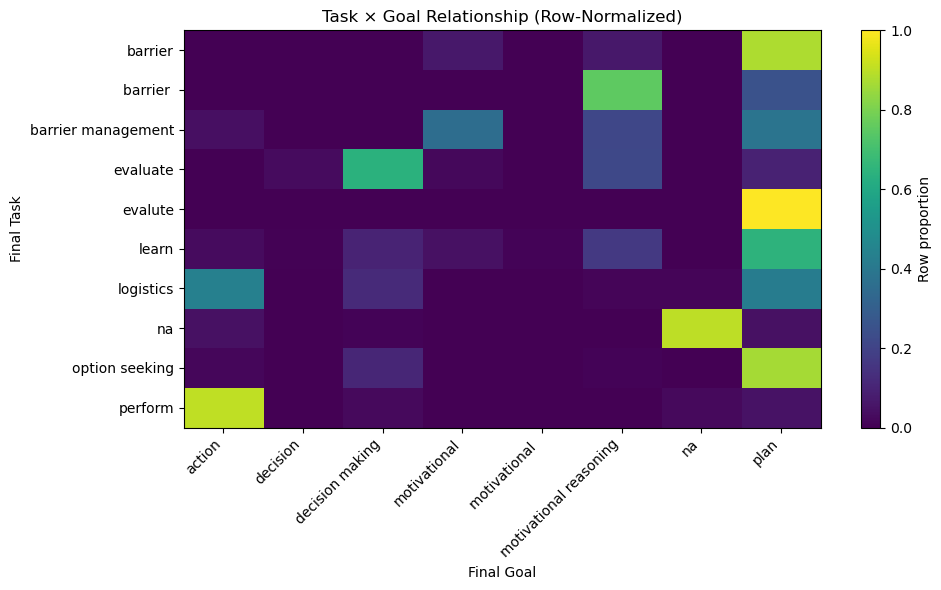

In [30]:
plt.figure(figsize=(10, 6))
plt.imshow(task_goal_rowpct, aspect='auto')
plt.xticks(range(len(task_goal_rowpct.columns)), task_goal_rowpct.columns, rotation=45, ha='right')
plt.yticks(range(len(task_goal_rowpct.index)), task_goal_rowpct.index)
plt.colorbar(label='Row proportion')
plt.title('Task × Goal Relationship (Row-Normalized)')
plt.xlabel('Final Goal')
plt.ylabel('Final Task')
plt.tight_layout()
plt.show()

## 6. Type × Goal relationship

This section asks whether certain information forms are directly associated with certain user goals.

Why this matters:
- It helps identify whether users request different kinds of AI outputs depending on their ultimate objective.
- For example, recommendation-type queries may align more strongly with action-oriented goals than purely factual queries do.

In [31]:
type_goal_counts = pd.crosstab(rel_df['final_type'], rel_df['final_goal'])
type_goal_counts

final_goal,action,decision,decision making,motivational,motivational,motivational reasoning,na,plan
final_type,,,,,,,,
comparative,0,0,24,0,0,0,0,2
experiential,0,0,7,0,0,34,0,35
factual,9,2,30,0,0,5,2,225
how-to,2,0,0,0,0,0,0,0
how-to (procedural),15,0,0,0,0,11,0,92
how-to (psyc),0,0,0,0,0,1,0,0
how-to (psychological),0,0,0,26,0,5,0,14
ideas,0,0,1,0,0,0,0,4
ideas/options,24,1,106,0,0,4,0,754


In [32]:
type_goal_rowpct = pd.crosstab(rel_df['final_type'], rel_df['final_goal'], normalize='index')
type_goal_rowpct.round(3)

final_goal,action,decision,decision making,motivational,motivational,motivational reasoning,na,plan
final_type,,,,,,,,
comparative,0.000,0.000,0.923,0.000,0.000,0.000,0.000,0.077
experiential,0.000,0.000,0.092,0.000,0.000,0.447,0.000,0.461
factual,0.033,0.007,0.110,0.000,0.000,0.018,0.007,0.824
how-to,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
how-to (procedural),0.127,0.000,0.000,0.000,0.000,0.093,0.000,0.780
how-to (psyc),0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000
how-to (psychological),0.000,0.000,0.000,0.578,0.000,0.111,0.000,0.311
ideas,0.000,0.000,0.200,0.000,0.000,0.000,0.000,0.800
ideas/options,0.027,0.001,0.119,0.000,0.000,0.004,0.000,0.848


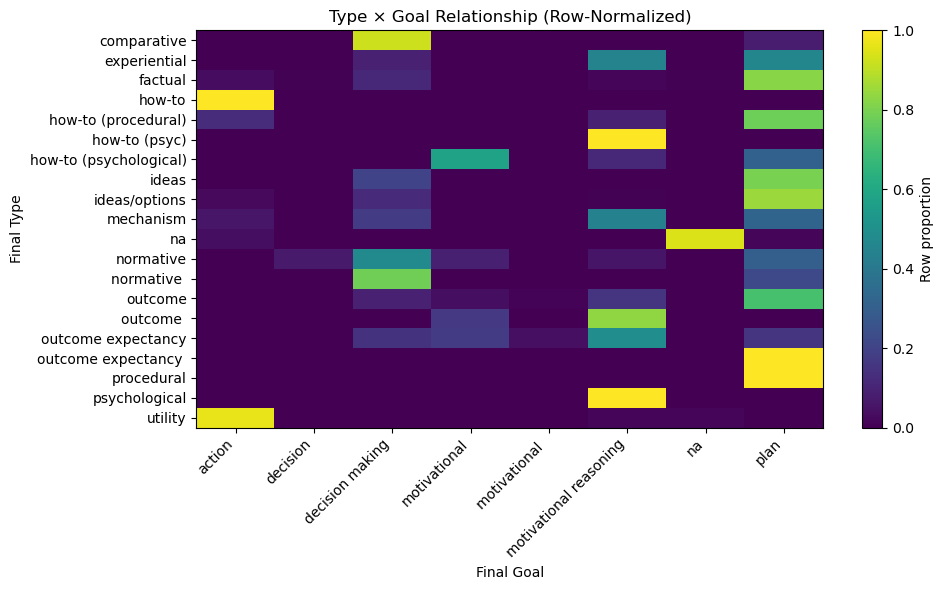

In [33]:
plt.figure(figsize=(10, 6))
plt.imshow(type_goal_rowpct, aspect='auto')
plt.xticks(range(len(type_goal_rowpct.columns)), type_goal_rowpct.columns, rotation=45, ha='right')
plt.yticks(range(len(type_goal_rowpct.index)), type_goal_rowpct.index)
plt.colorbar(label='Row proportion')
plt.title('Type × Goal Relationship (Row-Normalized)')
plt.xlabel('Final Goal')
plt.ylabel('Final Type')
plt.tight_layout()
plt.show()

## 7. Full behavioral pipeline

Now we combine all three labels into a single pipeline.

Why this matters:
- A query is often more interpretable as a **sequence** than as three separate labels.
- This lets us identify common behavioral archetypes in human-AI interaction.
- These patterns can be useful in papers because they are intuitive and easy to describe.

In [34]:
rel_df['pipeline'] = (
    rel_df['final_type'].astype(str) + ' → ' +
    rel_df['final_task'].astype(str) + ' → ' +
    rel_df['final_goal'].astype(str)
)

pipeline_counts = rel_df['pipeline'].value_counts().reset_index()
pipeline_counts.columns = ['pipeline', 'count']
pipeline_counts['percent'] = pipeline_counts['count'] / len(rel_df) * 100
pipeline_counts.head(20)

,pipeline,count,percent
0,ideas/options → option seeking → plan,687,32.482270
1,na → na → na,201,9.503546
2,factual → learn → plan,198,9.361702
3,ideas/options → option seeking → decision making,89,4.208038
4,outcome → learn → plan,75,3.546099
5,outcome expectancy → learn → motivational reasoning,70,3.309693
6,ideas/options → learn → plan,50,2.364066
7,how-to (procedural) → learn → plan,48,2.269504
8,normative → evaluate → decision making,31,1.465721
9,experiential → learn → plan,31,1.465721


### Three-column view of the most common full pipelines

Because the full pipeline is built from three labels, it is often helpful to inspect the most common combinations again in a compact three-column table.

Why this matters:
- It makes the most frequent `type → task → goal` patterns easier to read.
- It is useful for reporting the strongest behavioral archetypes in a paper or slide.
- It keeps the three components visible as separate columns instead of only as one joined string.

In [35]:
top_full_pipelines = (
    rel_df.groupby(['final_type', 'final_task', 'final_goal'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

top_full_pipelines['percent'] = top_full_pipelines['count'] / len(rel_df) * 100
top_full_pipelines.head(20)

,final_type,final_task,final_goal,count,percent
61,ideas/options,option seeking,plan,687,32.482270
71,na,na,na,201,9.503546
18,factual,learn,plan,198,9.361702
59,ideas/options,option seeking,decision making,89,4.208038
92,outcome,learn,plan,75,3.546099
101,outcome expectancy,learn,motivational reasoning,70,3.309693
53,ideas/options,learn,plan,50,2.364066
33,how-to (procedural),learn,plan,48,2.269504
9,experiential,learn,plan,31,1.465721
74,normative,evaluate,decision making,31,1.465721


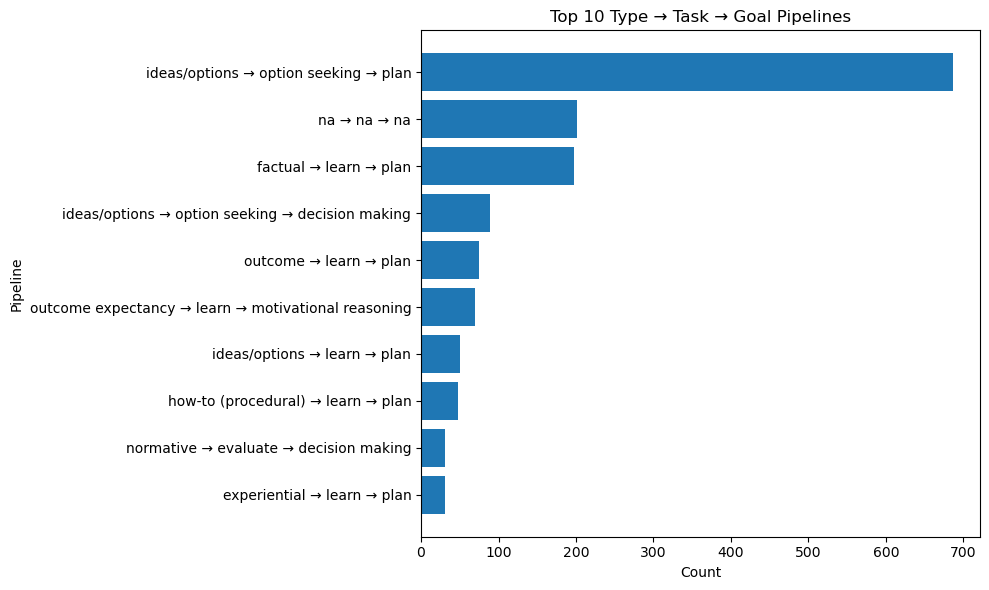

In [36]:
top_pipelines = pipeline_counts.head(10).iloc[::-1]

plt.figure(figsize=(10, 6))
plt.barh(top_pipelines['pipeline'], top_pipelines['count'])
plt.title('Top 10 Type → Task → Goal Pipelines')
plt.xlabel('Count')
plt.ylabel('Pipeline')
plt.tight_layout()
plt.show()

## 8. Most common pairwise combinations

Besides the full pipeline, it is also useful to identify the most common two-way combinations.

Why this matters:
- Two-way combinations are often easier to discuss in results sections.
- They help reveal the strongest relationships without requiring the full complexity of three labels.

In [37]:
rel_df['type_task_pair'] = rel_df['final_type'].astype(str) + ' | ' + rel_df['final_task'].astype(str)
rel_df['task_goal_pair'] = rel_df['final_task'].astype(str) + ' | ' + rel_df['final_goal'].astype(str)
rel_df['type_goal_pair'] = rel_df['final_type'].astype(str) + ' | ' + rel_df['final_goal'].astype(str)

print('Top Type | Task pairs')
display(rel_df['type_task_pair'].value_counts().head(10).to_frame('count'))

print('Top Task | Goal pairs')
display(rel_df['task_goal_pair'].value_counts().head(10).to_frame('count'))

print('Top Type | Goal pairs')
display(rel_df['type_goal_pair'].value_counts().head(10).to_frame('count'))

Top Type | Task pairs


,count
type_task_pair,
ideas/options | option seeking,793
factual | learn,223
na | na,211
outcome expectancy | learn,132
outcome | learn,105
ideas/options | learn,63
how-to (procedural) | learn,61
normative | evaluate,46
experiential | learn,43


Top Task | Goal pairs


,count
task_goal_pair,
option seeking | plan,721
learn | plan,457
na | na,203
learn | motivational reasoning,117
option seeking | decision making,91
evaluate | decision making,88
learn | decision making,72
perform | action,37
logistics | action,33


Top Type | Goal pairs


,count
type_goal_pair,
ideas/options | plan,754
factual | plan,225
na | na,202
ideas/options | decision making,106
how-to (procedural) | plan,92
outcome | plan,78
outcome expectancy | motivational reasoning,71
utility | action,58
experiential | plan,35


## 9. Diversity of labels

This section measures how concentrated or varied the labels are.

Why this matters:
- If one category dominates heavily, that affects interpretation.
- If many categories appear with similar frequency, the dataset may reflect more diverse AI usage behavior.

In [38]:
print('Number of unique final_type labels:', rel_df['final_type'].nunique())
print('Number of unique final_task labels:', rel_df['final_task'].nunique())
print('Number of unique final_goal labels:', rel_df['final_goal'].nunique())
print('Number of unique pipelines:', rel_df['pipeline'].nunique())

Number of unique final_type labels: 20
Number of unique final_task labels: 10
Number of unique final_goal labels: 8
Number of unique pipelines: 114


## 10. Example rows from common pipelines

To keep the quantitative analysis grounded, it helps to inspect example queries from frequent pipelines.

Why this matters:
- It helps verify whether the pipeline interpretation makes sense.
- It gives useful qualitative examples for presentations or paper writing.

In [39]:
top_pipeline_names = pipeline_counts['pipeline'].head(3).tolist()

for p in top_pipeline_names:
    print('\n' + '='*80)
    print('Pipeline:', p)
    display(
        rel_df.loc[rel_df['pipeline'] == p, ['participant_no', 'week_no', 'query', 'final_type', 'final_task', 'final_goal']]
        .head(5)
    )


Pipeline: ideas/options → option seeking → plan


,participant_no,week_no,query,final_type,final_task,final_goal
0,102,Week 1,foods to avoid while losing body fat,ideas/options,option seeking,plan
1,102,Week 1,foods to avoid while losing body fat,ideas/options,option seeking,plan
2,102,Week 1,foods to eat that help lose weight,ideas/options,option seeking,plan
3,102,Week 1,foods to eat that help lose weight,ideas/options,option seeking,plan
4,102,Week 1,vegan foods to eat that help lose weight,ideas/options,option seeking,plan



Pipeline: na → na → na


,participant_no,week_no,query,final_type,final_task,final_goal
176,102,Week 4,charlotte stingray give birth,na,na,na
203,119,Week 3,lense,na,na,na
204,119,Week 3,https://docs.google.com/document/d/1JvA9x6iJetLrRtkZG0qB1oQ_7QyON3xEYUHsEwTu1UQ/edit?urp=gmail_link,na,na,na
234,119,Week 4,paypal login,na,na,na
250,119,Week 4,https://mx.technolutions.net/ss/c/u001.yAWHLkb7QxrqAOlNdz1qpSDd1V_9_bPbG_LV2M3mES7JCnPdmpVOygwExPEdp7zFrX-8JlCYPorb9...,na,na,na



Pipeline: factual → learn → plan


,participant_no,week_no,query,final_type,final_task,final_goal
60,102,Week 2,what happens when you don't eat enough when working out,factual,learn,plan
61,102,Week 2,what happens your bodywhen you don't eat enough when working out,factual,learn,plan
63,102,Week 2,how many calories do you lose in a day,factual,learn,plan
64,102,Week 2,how many calories do you lose in a day normally,factual,learn,plan
65,102,Week 2,how many calories do you lose in a day normally,factual,learn,plan


## 11. Takeaways from Notebook 2

By the end of this notebook, you should know:

- which information types tend to align with which tasks,
- which tasks tend to align with which goals,
- and which full behavioral pipelines are most common.

This notebook is important for HCI/AI research because it helps describe user interaction not as isolated prompts, but as **structured behavior with information, task, and motivation components**.